<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula6a_Linear_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseado nos códigos das aulas anteriores, faça:

## 1. Carregar o dataset breast cancer.



In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(f"Dataset loaded with {cancer.data.shape[0]} samples and {cancer.data.shape[1]} features.")

Dataset loaded with 569 samples and 30 features.


## 2. Escolher 1 característica do dataset. A que tenha a maior correlação com o rótulo (target).

In [ ]:
import pandas as pd
import numpy as np

# Create a DataFrame from the cancer dataset
df_cancer = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target

# Calculate the correlation of each feature with the target
correlations = df_cancer.corr(numeric_only=True)['target'].drop('target')

# Sort the correlations by absolute value in descending order
sorted_correlations = correlations.abs().sort_values(ascending=False)

print("Correlation of features with the target variable (sorted by absolute value):")
print(sorted_correlations)

# Get the feature with the highest absolute correlation
most_correlated_feature = sorted_correlations.index[0]
print(f"\nFeature with the highest absolute correlation: {most_correlated_feature}")


Correlation of features with the target variable (sorted by absolute value):
worst concave points       0.793566
worst perimeter            0.782914
mean concave points        0.776614
worst radius               0.776454
mean perimeter             0.742636
worst area                 0.733825
mean radius                0.730029
mean area                  0.708984
mean concavity             0.696360
worst concavity            0.659610
mean compactness           0.596534
worst compactness          0.590998
radius error               0.567134
perimeter error            0.556141
area error                 0.548236
worst texture              0.456903
worst smoothness           0.421465
worst symmetry             0.416294
mean texture               0.415185
concave points error       0.408042
mean smoothness            0.358560
mean symmetry              0.330499
worst fractal dimension    0.323872
compactness error          0.292999
concavity error            0.253730
fractal dimension error

In [ ]:
temp_dataset = df_cancer[[most_correlated_feature]].copy()
print(f"Temporary dataset created with {temp_dataset.shape[0]} samples and 1 feature ('{most_correlated_feature}').")
print("First 5 rows of the temporary dataset:")
print(temp_dataset.head())

Temporary dataset created with 569 samples and 1 feature ('worst concave points').
First 5 rows of the temporary dataset:
   worst concave points
0                0.2654
1                0.1860
2                0.2430
3                0.2575
4                0.1625


In [ ]:
from sklearn.model_selection import train_test_split

X = temp_dataset
y = df_cancer['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 1)
X_test shape: (114, 1)
y_train shape: (455,)
y_test shape: (114,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler only on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the *same* fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Data normalization complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("First 5 rows of X_train_scaled:")
print(X_train_scaled[:5])

Data normalization complete.
X_train_scaled shape: (455, 1)
X_test_scaled shape: (114, 1)
First 5 rows of X_train_scaled:
[[ 0.9320124 ]
 [ 2.6989469 ]
 [-0.97023893]
 [-0.80948314]
 [-1.35458167]]


## 3. Implementar um classificador linear utilizando descida de gradiente ou equação normal (pseudo-inversa). Faça uma implementação que aceite mais de 1 característica.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class LinearClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
        for _ in range(self.num_iterations):
            y_predicted = self.predict(X)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = linear_model > 0
        return y_predicted.astype(int)

model = LinearClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9120879120879121


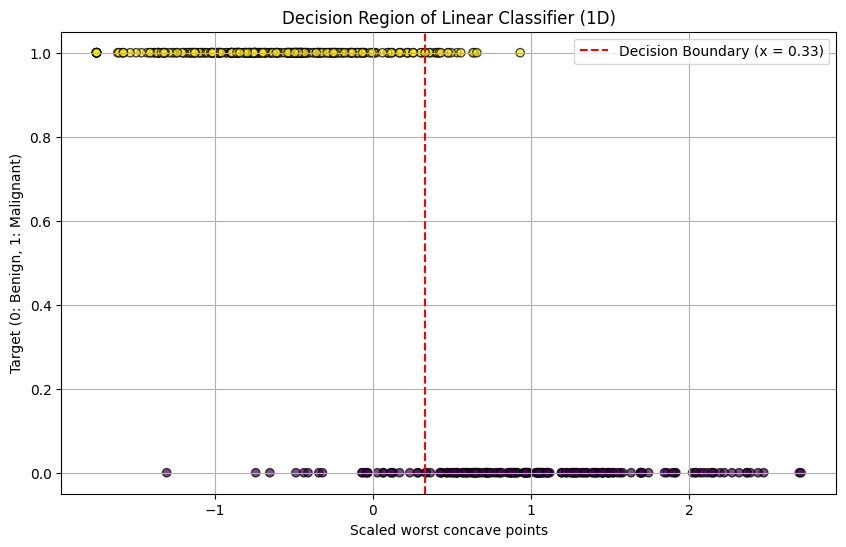

In [ ]:
import matplotlib.pyplot as plt

# Get the learned weights and bias from the model
weights = model.weights[0] # Assuming a single feature
bias = model.bias

# Calculate the decision boundary
# For a linear classifier, the decision boundary is where w*x + b = 0
# So, x = -b / w
decision_boundary_x = -bias / weights

# Create a scatter plot of the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train, c=y_train, cmap='viridis', edgecolors='k', alpha=0.7)

# Plot the decision boundary
plt.axvline(x=decision_boundary_x, color='red', linestyle='--', label=f'Decision Boundary (x = {decision_boundary_x:.2f})')

plt.title('Decision Region of Linear Classifier (1D)')
plt.xlabel(f'Scaled {most_correlated_feature}')
plt.ylabel('Target (0: Benign, 1: Malignant)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Plotar o MSE em função do valor de intercept e em função do valor do único coef.

In [ ]:
model = LinearClassifier()
model.fit(X_train_scaled, y_train)
print(model.bias, model.weights)

0.00026373626373627174 [-0.00079637]


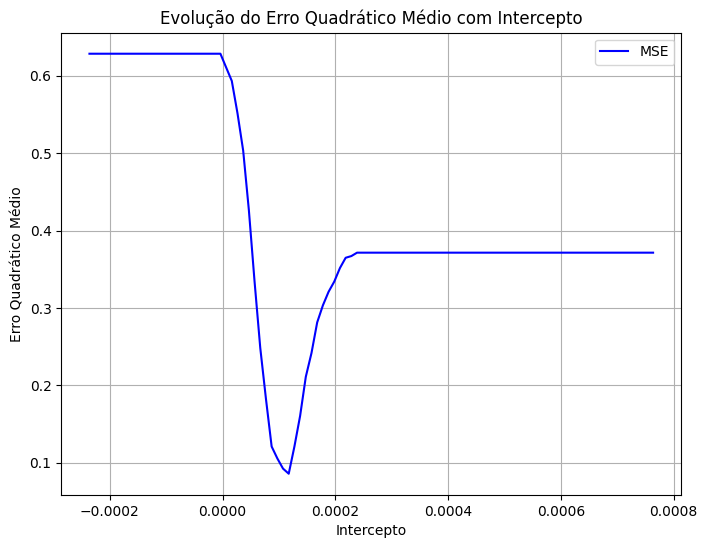

In [ ]:
from sklearn.metrics import mean_squared_error

def plot_mse_by_intercept(model, X, y):
  intercept = model.bias
  i_min = intercept - 0.0005
  i_max = intercept + 0.0005
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.bias = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  model.bias = intercept
  plt.xlabel("Intercepto")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Intercepto")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_intercept(model, X_train, y_train)

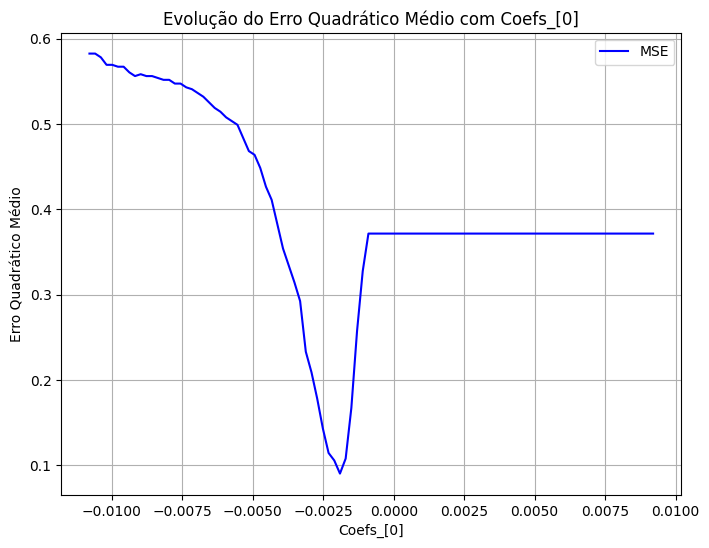

In [ ]:
def plot_mse_by_coef0(model, X, y):
  coef0 = model.weights[0]
  i_min = coef0 - 0.01
  i_max = coef0 + 0.01
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.weights[0] = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  model.weights[0] = coef0
  plt.xlabel("Coefs_[0]")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Coefs_[0]")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_coef0(model, X_train, y_train)

## 5. Comparar a performance da sua implementação com algum outro classificador linear do Scikit-Learn.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9385964912280702


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9736842105263158
